# Лабораторная работа №3

In [1]:
import pandas as pd
import sklearnex
from imblearn.over_sampling import SMOTE

sklearnex.patch_sklearn()
import seaborn as sns
RANDOM_STATE = 13
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import optuna

Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


In [2]:
data = pd.read_csv("datasets/neo.csv", index_col="Unnamed: 0")
data

,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude,hazardous
0,-0.889019,-0.892421,0.316109,-1.612480,0.892109,0
1,-0.405274,-0.407831,-1.593181,-0.196165,0.406521,0
2,0.043918,0.042145,0.286110,1.266990,-0.044382,0
3,-0.750806,-0.753967,-0.258175,-1.094244,0.753369,0
4,0.734983,0.734416,0.777089,1.531822,-0.738079,0
...,...,...,...,...,...,...
90831,-0.819912,-0.823194,-0.982506,-1.585159,0.822739,0
90832,0.562217,0.561348,-0.921528,-0.158712,-0.564655,0
90833,-0.301614,-0.303991,2.706200,0.789522,0.302466,0
90834,-0.128848,-0.130923,-0.090366,-0.452655,0.129042,0


In [3]:
data["hazardous"].value_counts()

hazardous
0    81996
1     8840
Name: count, dtype: int64

Существует большой дисбаланс классов. Количество неопасных объектов гораздо больше количества опасных объектов.

Text(0, 0.5, 'counts')

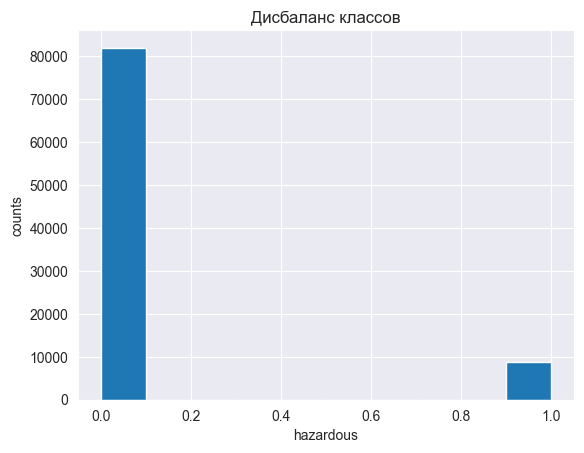

In [4]:
data["hazardous"].hist()
plt.title("Дисбаланс классов")
plt.xlabel("hazardous")
plt.ylabel("counts")

## Разделение выборки

In [5]:
random_state = 13
X = data.drop("hazardous", axis=1)
y = data["hazardous"]

X_train, X_val_test, y_train, y_val_test = train_test_split(X, y, test_size=0.2, random_state = RANDOM_STATE, stratify=y)
X_test, X_val, y_test, y_val  = train_test_split(X_val_test, y_val_test, test_size=0.5, random_state = RANDOM_STATE, stratify=y_val_test)

print(f"Размер исходной выборки: {len(X)}\n"
      f"Размер тренировочной выборки: {len(X_train)}\n"
      f"Размер валидационной выборки: {len(X_val)}\n"
      f"Размер тестовой выборки: {len(X_test)}")

Размер исходной выборки: 90836
Размер тренировочной выборки: 72668
Размер валидационной выборки: 9084
Размер тестовой выборки: 9084


In [16]:
print(f"Баланс классов в исходной выборке: {y.value_counts()}\n"
      f"Баланс классов в тренировочной выборке: {y_train.value_counts()}\n"
      f"Баланс классов в валидационной выборке: {y_val.value_counts()}\n"
      f"Баланс классов в тестовой выборке: {y_test.value_counts()}\n")

Баланс классов в исходной выборке: hazardous
0    81996
1     8840
Name: count, dtype: int64
Баланс классов в тренировочной выборке: hazardous
0    65596
1     7072
Name: count, dtype: int64
Баланс классов в валидационной выборке: hazardous
0    8200
1     884
Name: count, dtype: int64
Баланс классов в тестовой выборке: hazardous
0    8200
1     884
Name: count, dtype: int64



Для решения проблемы дисбаланса классов используем алгоритм SMOTE, реализовав стратегию over-sampling. Датасет содержит всего около 10 тысяч записей и в рамках стратегии under-sampling значительная часть данных была бы утеряна с целью балансировки классов. Тем самым произошла бы утеря большого количества данных, которые могли бы быть важными для обучения модели.

In [14]:
estimator = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = estimator.fit_resample(X_train, y_train)

print(f"Баланс классов тренировочной выборки после сэмплирования: {y_train_res.value_counts(normalize=True)}\n")

Баланс классов тренировочной выборки после сэмплирования: hazardous
0    0.5
1    0.5
Name: proportion, dtype: float64



In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import optuna

def train_models_with_val(X_train, y_train, X_val, y_val, models_config):
    result={}
    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        type_of_reg = model_info["reg"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            random_state=42,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            model = type_of_reg(**trial_params)
            model.fit(X_train, y_train)
            score = mean_squared_error(y_val, model.predict(X_val))
            return score

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = type_of_reg(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result

In [ ]:
def train_models_with_cross(X_train, y_train, models_config):

    result={}

    for name, model_info in models_config.items():

        param_grid = model_info["param_grid"]
        type_of_reg = model_info["reg"]

        grid_search_model = GridSearchCV(
            param_grid=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            cv=3
        )

        grid_search_model.fit(X_train, y_train)

        random_search_model = RandomizedSearchCV(
            param_distributions=param_grid,
            estimator=type_of_reg(max_iter=1000),
            scoring="neg_mean_squared_error",
            random_state=42,
            cv=3
        )

        random_search_model.fit(X_train, y_train)

        def objective(trial):
            trial_params = {}
            for p_name, p_values in param_grid.items():
                if isinstance(p_values[0], float):
                    trial_params[p_name] = trial.suggest_float(p_name, min(p_values), max(p_values), log=True)
                else:
                    trial_params[p_name] = trial.suggest_categorical(p_name, p_values)

            model = type_of_reg(**trial_params)
            model.fit(X_train, y_train)
            score = mean_squared_error(y_val, model.predict(X_val))
            return score

        study = optuna.create_study(direction='minimize')
        study.optimize(objective, n_trials=100, show_progress_bar=False)

        optuna_model = type_of_reg(**study.best_params)
        optuna_model.fit(X_train, y_train)

        result[name] = {}
        result[name]["GridSearch"] = {
            "model": grid_search_model.best_estimator_,
            "best_params": grid_search_model.best_params_
        }
        result[name]["RandomSearch"] = {
            "model": random_search_model.best_estimator_,
            "best_params": random_search_model.best_params_
        }
        result[name]["Optuna"] = {
            "model": optuna_model,
            "best_params": study.best_params
        }

    return result

In [ ]:
def train_with_cross_validation(X_train, y_train, metrics, mo):
    folds = StratifiedKFold(n_splits = 10, shuffle = True)
